# 计算机视觉系统组成与原理



在介绍系统组成和原理前，展示一个清晰的计算机视觉系统工作流程图，帮助我们建立整体概念。


<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107090748030.png" width="1000px"/></div>
</div>



## 1. 图像采集设备（“眼睛”）

*   **作用：** 负责从现实世界中获取图像或视频数据，将其转换为数字信号。
*   **常见设备：**
    *   **摄像头：** 最常见的图像采集设备，如手机摄像头、工业相机、网络摄像头等。
    <div class='insertContainerBox column'>
    <div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107092529177.jpg" width="400px"/></div>
    </div>
    
    *   **传感器：** 除了可见光摄像头，还有红外传感器、X光传感器、超声波传感器等，
        用于获取不同波段或类型的图像数据。
    *   **扫描仪：** 用于获取平面文档或物体的图像。
    


*   **工作原理：** 光线通过镜头聚焦到感光元件（如CCD或CMOS），感光元件将光信号
    转换为电信号，再经过模数转换器（ADC）转换为数字图像数据。


## 2. 图像预处理（“清洁工”）

*   **作用：** 对原始图像数据进行处理，去除噪声、增强图像质量、调整尺寸和格式，使其更适合后续的分析。
*   **常见操作：**
    *   **降噪：** 减少图像中的随机干扰，使图像更清晰。
    *   **增强：** 提高图像的对比度、亮度，突出感兴趣区域。
    *   **尺寸调整：** 将图像缩放到统一的大小，便于算法处理。
    *   **色彩空间转换：** 将图像从 RGB 转换为灰度图或其他色彩空间。
*   **重要性：** 预处理是提升后续算法性能的关键一步，“垃圾进，垃圾出”的道理同样适用于图像处理。

“垃圾进垃圾出”是一种常见的问题，指由于输入数据的低质量或错误，导致输出结果的不准确和无价值。这种现象在很多领域都有所体现，包括医疗、金融、人工智能等。

下面简单展示一下图像预处理，展示一下如何使用 OpenCV 生成灰度图。

In [ ]:
# 安装OpenCV和Matplotlib
!pip install opencv-python matplotlib

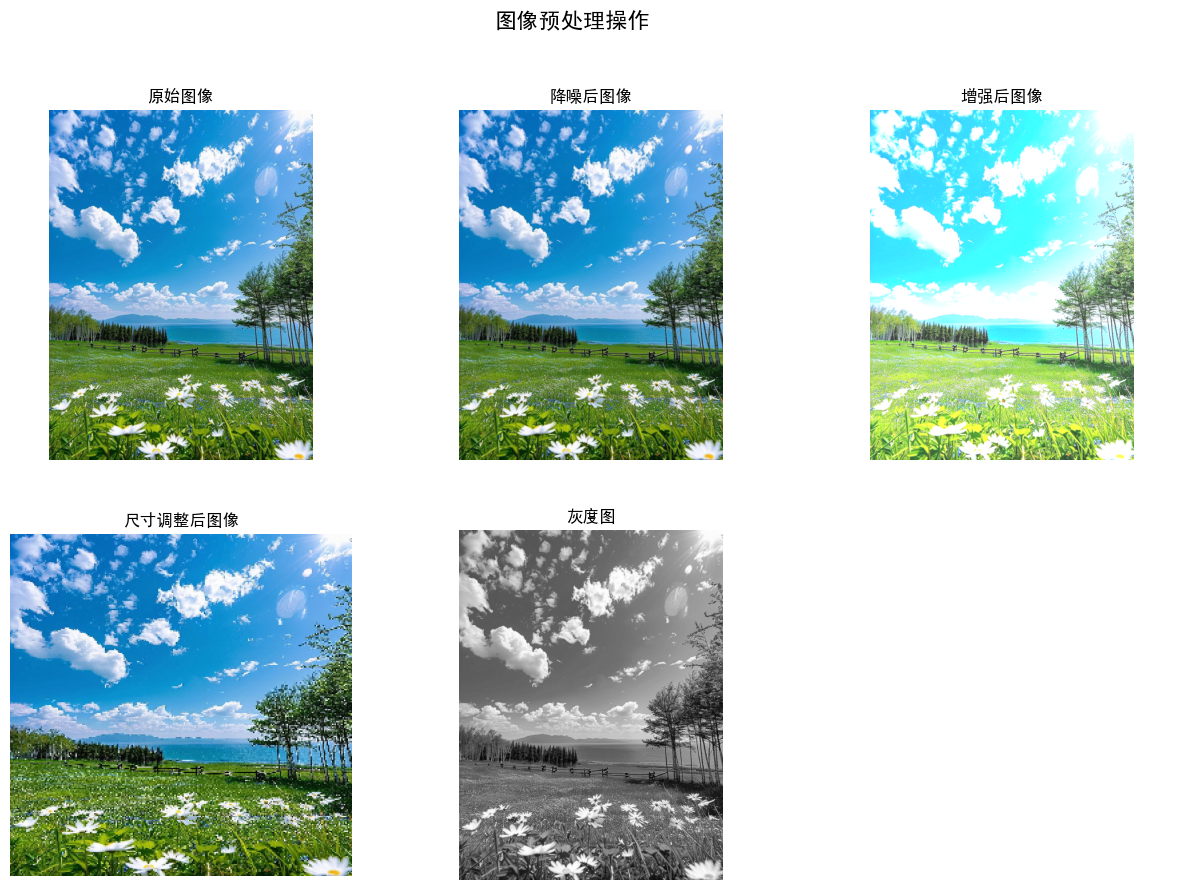

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 读取图像（如果1.jpg不存在，会创建一个示例图像）
try:
    image = cv2.imread('1.jpg')
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
except:
    # 创建示例图像：带有噪声的简单图形
    image = np.zeros((300, 300, 3), dtype=np.uint8)
    cv2.rectangle(image, (50, 50), (250, 250), (255, 0, 0), 2)  # 红色矩形
    cv2.circle(image, (150, 150), 50, (0, 255, 0), -1)  # 绿色圆形
    image += np.random.randint(0, 50, size=image.shape, dtype=np.uint8)  # 添加随机噪声
    print("未找到1.jpg，已生成示例测试图像")

# 1. 降噪：减少图像中的随机干扰，使图像更清晰
# 使用高斯滤波进行降噪
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

# 2. 增强：提高图像的对比度、亮度，突出感兴趣区域
# 调整亮度和对比度
enhanced_image = cv2.convertScaleAbs(image, alpha=1.5, beta=50)  # alpha: 对比度，beta: 亮度

# 3. 尺寸调整：将图像缩放到统一的大小，便于算法处理
# 缩放到固定大小（例如256x256）
resized_image = cv2.resize(image, (256, 256))

# 4. 色彩空间转换：将图像从 RGB 转换为灰度图或其他色彩空间
# 转换为灰度图
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# 可视化结果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.suptitle("图像预处理操作", fontsize=16)

# 原始图像
axes[0, 0].imshow(image)
axes[0, 0].set_title("原始图像")
axes[0, 0].axis("off")

# 降噪后的图像
axes[0, 1].imshow(blurred_image)
axes[0, 1].set_title("降噪后图像")
axes[0, 1].axis("off")

# 增强后的图像
axes[0, 2].imshow(enhanced_image)
axes[0, 2].set_title("增强后图像")
axes[0, 2].axis("off")

# 尺寸调整后的图像
axes[1, 0].imshow(resized_image)
axes[1, 0].set_title("尺寸调整后图像")
axes[1, 0].axis("off")

# 灰度图
axes[1, 1].imshow(gray_image, cmap="gray")
axes[1, 1].set_title("灰度图")
axes[1, 1].axis("off")

# 第二行第三个位置为空白，避免显示错误
axes[1, 2].axis("off")

# 显示结果
# plt.tight_layout()
plt.show()

## 3. 特征提取（“分析师”）

*   **作用：** 从预处理后的图像中识别和提取出对任务有用的关键信息，这些信息被
    称为“特征”。
*   **理解：** 机器不像人一样直接“看懂”图像，而是通过图像中的点、线、边缘、
    纹理、颜色、形状等信息来“理解”内容。特征提取就是把这些人类难以直接描述
    但对机器很重要的信息提取出来。
*   **类比：** 就像我们识别一个人，不是看他的每一个细胞，而是看他的五官、发型、
    身高、体型等关键特征。


下面我们通过代码来进行特征提取的操作。

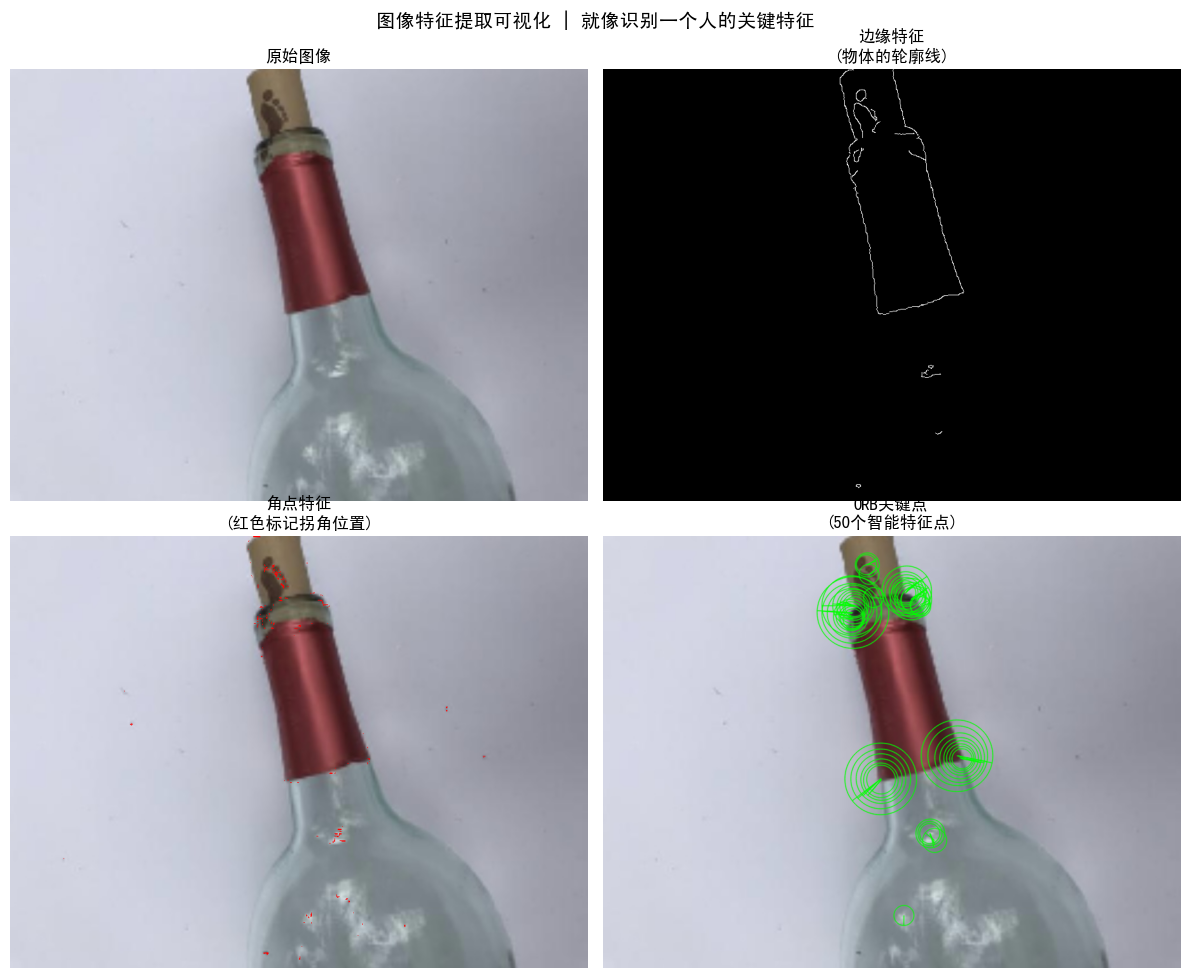

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 读取图像（如果1.jpg不存在，会创建一个示例图像）
try:
    image = cv2.imread('1.jpg')
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
except:
    # 创建示例图像：棋盘格+方块，更容易观察特征
    image = np.zeros((300, 300, 3), dtype=np.uint8)
    image[50:150, 50:150] = [255, 0, 0]  # 蓝色方块
    image[150:250, 150:250] = [0, 255, 0]  # 绿色方块
    cv2.rectangle(image, (10, 10), (290, 290), (255, 255, 255), 2)  # 白色边框
    print("未找到1.jpg，已生成示例测试图像")

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# ==================== 特征提取演示 ====================
# 类比：就像医生看病，不是看全身每个细胞，而是看"体温、血压、脉搏"等关键指标

# 1. 边缘特征（Canny）- 提取物体的轮廓线
# 类比：就像用线条勾勒出一个人的"剪影"
edges = cv2.Canny(gray, 50, 150)

# 2. 角点特征（Harris）- 提取图像中的"关键点"
# 类比：就像识别建筑物的"墙角、桌角"等拐角位置
gray_float = np.float32(gray)
harris = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)
harris_image = image.copy()
harris_image[harris > 0.01 * harris.max()] = [255, 0, 0]  # 角点标记为红色

# 3. ORB特征点 - 更智能的关键点提取
# 类比：就像识别指纹上的"脊线终点、分叉点"等特征点
orb = cv2.ORB_create(nfeatures=50)
keypoints, descriptors = orb.detectAndCompute(gray, None)
# 绘制特征点
orb_image = cv2.drawKeypoints(image, keypoints, None, color=(0, 255, 0), 
                               flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 4. 颜色直方图 - 提取颜色分布特征
# 类比：就像描述一个人"穿什么颜色的衣服，颜色占比多少"
colors = ('r', 'g', 'b')
color_features = {}
for i, color in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [16], [0, 256])
    color_features[color] = hist.flatten()  # 保存每种颜色的分布

# ==================== 可视化结果 ====================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle('图像特征提取可视化 | 就像识别一个人的关键特征', fontsize=14)

# 原始图像
axes[0, 0].imshow(image)
axes[0, 0].set_title('原始图像')
axes[0, 0].axis('off')

# 边缘特征
axes[0, 1].imshow(edges, cmap='gray')
axes[0, 1].set_title('边缘特征\n(物体的轮廓线)')
axes[0, 1].axis('off')

# Harris角点
axes[1, 0].imshow(harris_image)
axes[1, 0].set_title('角点特征\n(红色标记拐角位置)')
axes[1, 0].axis('off')

# ORB特征点
axes[1, 1].imshow(orb_image)
axes[1, 1].set_title(f'ORB关键点\n({len(keypoints)}个智能特征点)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



## 4. 模式识别/分析（“思考者”）

*   **作用：** 基于提取到的特征，使用算法对图像内容进行分类、检测、识别、分割或
    跟踪，从而理解图像的含义。
*   **常见任务：**
    *   **图像分类：** 判断图像属于哪个类别（如猫、狗、汽车）。
    *   **目标检测：** 在图像中找出特定物体的位置，并用矩形框标注出来（如检测人脸、
        车辆）。
    *   **图像分割：** 将图像中的每个像素点分到不同的类别，实现对物体的精确划分
        （如分割出图像中的天空、道路、行人）。
    *   **目标跟踪：** 在视频序列中持续追踪特定物体的位置和运动。
*   **核心：** 这一阶段是计算机视觉的“大脑”，它通过学习大量的样本数据，掌握了
    从特征到语义的映射关系。


### 4.1 图像分类

图像分类是计算机视觉领域的基础任务，也是应用比较广泛的任务。图像分类用来解决“是什么”的问题，如给定一张图片，用标签描述图片的主要内容。图像分类的典型应用是车牌号码识别、交通灯识别、图像识别等。


<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107085500256.png" width="800px"/></div>
</div>

对于我们人类来说，可以毫不费力分辨猫、狗，是因为我们看见这些物体时，脑中会抽离出它们的基本特征（圆鼓鼓的头、尖尖的耳朵等），基本特征与物体的名称（标签）对应，再看到类似的物体，便可以识别它们。

对于计算机也是一样的，在使用计算机完成图像分类，大致可分为数据集采集、图片预处理、特征提取、分类器训练、模型评估。

图片预处理的目的是为消除图片中无用的信息，恢复有用的信息，更利于后续的特征提取的环节。简单的图像特征提取是提取物体的颜色、物体的轮廓等。分类器训练是将图像的特征与标签进行匹配。当分类器训练好之后，新的图片输入到分类器，查看分类的效果，便是模型评估。

### 4.2 目标检测

目标检测是最常见的计算机应用之一。目标检测用来解决“在哪里”的问题，如输入一张图片，输出待检测目标的类别和所在位置的坐标（矩形框的坐标值表示）。目标检测应用在姿态估计、车辆检测、人脸检测、口罩佩戴检查等。

<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107085741038.png" width="800px"/></div>
</div>

人类在看东西的时候，可以知道物体是什么和物体的位置。例如我们看到桌子上有一副眼镜，可以知道眼镜在桌子的什么位置，也可以知道那是一副眼镜。计算机视觉的初衷是让机器像人一样可以“看到”世界，机器是没有位置的感觉，而是通过矩形窗口在图片上滑动，获得物体的初始位置，再分析该窗口内的特征，是不是此物体。

早期，目标检测算法还没有使用深度学习，一般分为三个阶段：区域选取、特征提取、特征分类。区域选取这一步是为了对物体进行定位，采用了滑动窗口的策略，物体在图像中的位置和大小是变化的，因而需要不同的矩形窗口的比例，再通过矩形窗口在图像中从左到右、从上到下的滑动，可以获得图像上任意位置不同大小的物体。特征提取和特征分类的阶段是找到物体的类别，跟图像分类一致。


### 4.3 图像分割

图像分割是计算机视觉领域的重要研究方向之一，它根据图片的灰度、颜色、结构和纹理等特征将图像分成若干具有相似性质的区域。与目标检测相比较，图像分割更适用于精细的图像识别任务，更加精确的目标定位、以及图像的语义理解任务。图像分割的典型应用是卫星图像分析、自动驾驶，医学图像诊断等。


<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107085924280.png" width="800px"/></div>
</div>

当我们人类在看图像的时候，往往对图像中感兴趣的区域关注大，这个区域通常称为感兴趣区域或是前景，如图3中的人像分割将图片中的前景与其背景分开。算法根据前景和背景的颜色、纹理的不同来分割图像，首先通过分析找到前景和背景的颜色阈值；其次将图像中的每个像素值与阈值比较，分为两类；最后与原图映射获得前景。

常规的图像分割算法有基于阈值的分割、基于边缘检测的分割、区域生长算法、GrabCut 和分水岭算法等。在深度学习中，图像分割是一种端到端的像素级分类任务，就是给定一张图片，对图片上的每一个像素分类，可以按照分类模型的思路来做，不同的是，分割模型的输出是一张分割图。

### 4.4 人脸识别

人脸识别是一类十分热门的计算机技术研究领域，属于生物特征识别技术，可通过人脸图像所携带的生物特征信息来对人进行个体身份识别。从广义上来说，人脸识别包含构建人脸识别系统中所用到的一系列相关技术，包括人脸图像采集、图像处理、人脸定位、身份确认、身份查询等；而狭义的人脸识别则特指通过人脸图像进行身份确认的技术或系统。人脸识别通常也叫人像识别、面部识别等。


<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107090222283.png" width="800px"/></div>
</div>

对于我们人类来说，要想认出身边的一个人，首先需要睁眼，扭过头，看到他的脸，在看到他的脸之后，我们可能还要将他戴的帽子、眼镜排除，然后就可以根据他的长相在脑子里飞速搜索有没有认识的和这个长相相似的人，最后确定他到底是谁。

对于计算机也是一样的，在使用计算机完成人脸识别的时候，工作流程可分为如下几个步骤：

1. 第一步就是人脸图像采集，也就是 “睁开眼，扭过头”。人脸识别系统将通过各种各样的摄像头采集可见光图像、热成像图像、近红外图像等多种图像，并且还可以有静态、动态等不同情况作为区分。
2. 第二步就是人脸检测，也就是“看到他的脸”。这里可以使用各种人脸检测模型对画面中的人脸进行检测，生成对应的人脸框，之后就可以将人脸框以外的图像排除，专注于对人脸框内图像的探索。
3. 第三步就是数据处理。摄像头所拍摄的人脸可能有多种角度、表情、亮度等，需要通过例如光线补偿、灰度变换、直方图均衡化、归一化、几何校正、滤波以及锐化等方式对人脸图像进行处理，使其更能表现出系统所要的人脸特征。
4. 第四步就是对人脸图片进行特征提取和分类，例如使用深度神经网络挖掘图片的深层特征，并在特定维度上对深层特征进行分类，即可判断这个人是谁。

### 4.5 目标跟踪

目标跟踪是利用图像序列的上下文信息，对目标的外观和运动信息进行建模，从而对目标运动状态进行预测并标定目标位置。目标跟踪是计算机视觉中一个课题，具有重要的理论研究意义和应用价值，在智能视频监控系统、智能人机交互、智能交通和视觉导航系统等方面具有广泛应用。

<div class='insertContainerBox column'>
<div class='insertItem' align=center><img src="https://imgbed.momodel.cn/hv/20251107092140715.gif" width="800px"/></div>
</div>

目标跟踪的主要流程可以概括为：通过摄像头捕获图像序列，然后输入计算机计算出目标的位置，再根据目标相关的特征，将每一帧中的同一个目标关联起来从而得到目标运动的完整轨迹。

同一个目标关联起来的常用方法是将目标跟踪问题看作一个二分类问题，把图像分为前景图像（正样本）和背景图像（负样本），利用最适合实际场景的图像特征和最佳的分类方法，将目标从背景区域中区分出来，期间不断地在线更新分类器来估计目标的位置。

## 5. 决策与输出（“执行者”）

*   **作用：** 根据模式识别/分析的结果，系统做出相应的决策，并以某种形式输出结果。
*   **常见输出：**
    *   **显示识别结果：** 在屏幕上标注出检测到的物体，显示分类标签。
    *   **发出控制指令：** 如在智能门禁系统中，识别到人脸后发出开门指令；在自动驾驶中，
        识别到障碍物后发出刹车指令。
    *   **生成报告：** 在工业检测中，生成产品缺陷报告。
    *   **报警：** 在安防系统中，识别到异常行为后触发报警。
*   **例子：** 智能门禁系统识别出合法用户的人脸后，输出“开门”的指令。


## 6. 动手练习：填空题/连线题：将系统组成部分与功能进行匹配。

**题目：**
请将以下计算机视觉系统的组成部分与其对应的功能进行匹配（填空或连线）：

**组成部分：**
1.  图像采集设备
2.  图像预处理
3.  特征提取
4.  模式识别/分析
5.  决策与输出

**功能：**
A. 对原始图像进行降噪、增强、尺寸调整，使其更适合分析。             
B. 从现实世界中获取图像或视频数据。             
C. 根据分析结果，做出判断并发出指令或显示结果。             
D. 从图像中识别和提取有用的关键信息，如边缘、纹理、形状。             
E. 基于提取的特征，对图像内容进行分类、检测、识别或分割。

**参考答案：**
1.  图像采集设备 - B
2.  图像预处理 - A
3.  特征提取 - D
4.  模式识别/分析 - E
5.  决策与输出 - C
